# Pitch Mapping of Kepler lightcurves
Hands on Astronomical Data Sonification, Adrián García Riber, SVO 2026

https://archive.stsci.edu/missions-and-data/kepler

This work includes data collected by the Kepler mission and obtained from the MAST data archive at the Space Telescope Science Institute (STScI). Funding for the Kepler mission is provided by the NASA Science Mission Directorate. STScI is operated by the Association of Universities for Research in Astronomy, Inc., under NASA contract NAS 5–26555.

!pip3 install soundfile

In [1]:
from astropy.io import fits
from astropy.timeseries import TimeSeries
import numpy as np
import matplotlib.pylab as plt
import sounddevice as sd
import soundfile as sf

In [2]:
file = 'KeplerLightcurves/kplr011853905-2009166043257_llc.fits'

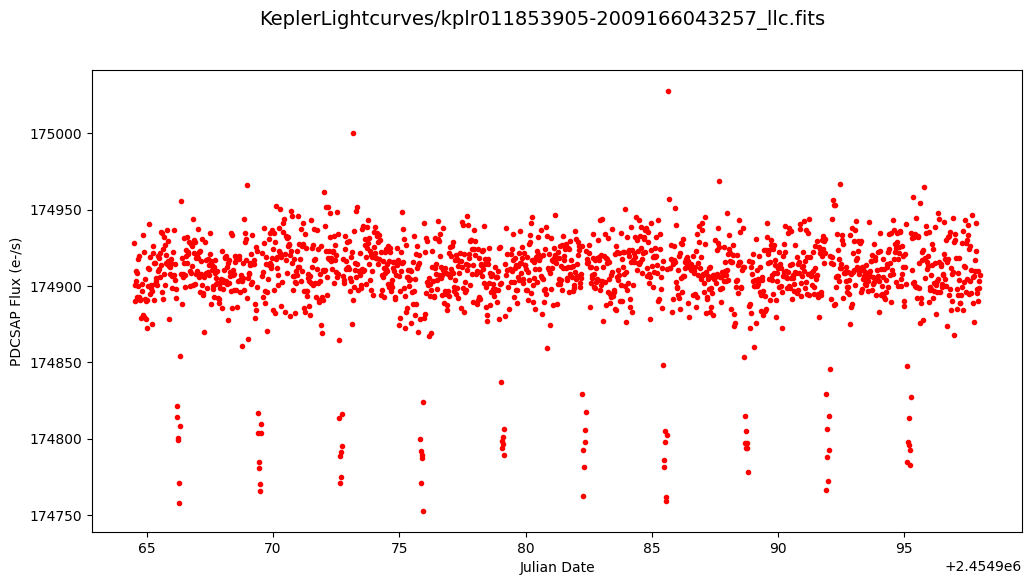

LC dimension:  1639


In [3]:
lightcurve = TimeSeries.read(file, format='kepler.fits', unit_parse_strict='silent') 

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle(file, size=14)  
time = lightcurve.time.jd
flux = lightcurve['pdcsap_flux']
ax.plot(time, flux, 'r.')
ax.set_xlabel('Julian Date')
ax.set_ylabel('PDCSAP Flux (e-/s)')
plt.show()
print("LC dimension: ", len(lightcurve['pdcsap_flux']))

Kepler 4 star (KIC 11853905), RA(2000): 285.6156 DEC(2000): 50.1358, available at the Mikulsky Archive for Space Telescope (MAST).  The curve shows planetary transits with relative depth of 0.87.10−3, orbital period of 3.213 days, and duration of about 3.95 hours around the sunlike star.

In [4]:
flux = flux.value

In [5]:
flux

array([174927.92, 174900.9 , 174890.14, ..., 174898.88, 174903.39,
       174907.34], shape=(1639,), dtype='>f4')

## Cleaning 'nans'

In [6]:
mask = ~np.isnan(flux)
clean_flux = flux[mask]
clean_times = np.arange(len(clean_flux))  

In [7]:
# Audio params (customize)
fs = 44100  # Hz
duration = 10  # Total sec
n_points = len(clean_flux)
dt_audio = duration / n_points
audio_samples = int(fs * duration)
t_audio = np.linspace(0, duration, audio_samples, endpoint=False)

# Interpolates the flux to audio timeline (handles any gaps implicitly)
flux_audio = np.interp(t_audio / duration * n_points, np.arange(n_points), clean_flux)

# Normalize & map to freq: 220-1760 Hz
flux_norm = (flux_audio - flux_audio.min()) / (flux_audio.max() - flux_audio.min()) # Max-Min normalization (low flux <=> low pitch)
flux_norm_inv = 1 - flux_norm # Pitch inversion, lowest fluxes generate the highest pitches (low flux <=> high pitch)

freqs = 440 * (2 ** ((flux_norm_inv * 24) - 12))  # MIDI-like semitones. Try eliminating the 440 factor

# Cumulative phase. Creates a glissando. Without it, you'd hear 1639 discrete beeps instead of the continuous pitch changes.
phase = 2 * np.pi * np.cumsum(freqs) / fs
audio = 0.03 * np.sin(phase)  # We could also add harmonics: +0.2*np.sin(2*phase)

# Export lossless FLAC
sf.write("Kepler.flac", audio, fs)
print(f"Saved {audio_samples/fs:.1f}s FLAC from {n_points} fluxes.")

# Playback
sd.play(audio , 44100)

Saved 10.0s FLAC from 1624 fluxes.
